In [1]:
import numpy as np
import pandas as pd
import math
import yfinance as yf
from scipy.stats import norm, binom
import matplotlib.pyplot as plt
from math import ceil
from IPython.display import display

Primeramente importamos librerias para poder trabajar sobre ellas.

#### Integrantes:
#### Ascencio Díaz Enrique
#### Lugo Salazar María Inés
#### Martínez Pineda Alison Azul
#### Ordáz López Julio César
#### Rivera Hernández Ollin César



# Función con API de yf para obtener cotizaciónes y log-Retornos


In [2]:
def coti_logr(activos,fi,ff):
  df_precios = yf.download(
    tickers=activos,
    start= fi,
    end= ff)

  df_precios = df_precios["Close"].dropna()
  df_precios.index = df_precios.index.date
  df_precios.index = pd.to_datetime(df_precios.index)

  for i in activos:
    df_precios[f"ri_{i}"]=np.log(df_precios[i]).diff()

  df_precios = df_precios.dropna()
  return df_precios

-Descarga precios de cierre de cada activo usando Yahoo Finance.

-Crea una columna de rendimientos logarítmicos:
ri=ln(Pt​)−ln(Pt−1​)

-Elimina los primeros valores que quedan como NaN después del diff().

-Devuelve un DataFrame con precios y rendimientos.

# Calculo de las primas

In [3]:
def black_scholes(S0, K, r, sigma, T, tipo):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if tipo == "call":
        return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)


-Calcula la prima de una opción europea usando la fórmula clásica:

* tipo = "call" → opción de compra

* tipo = "put" → opción de venta

Usa:

* distribución normal acumulada norm.cdf
* valor presente del strike

-Devuelve la prima de Black-Scholes.

In [4]:
def prima_binomial(S0, K, r, sigma, T, pasos, tipo):
    dt = T/pasos
    u = np.exp(sigma*np.sqrt(dt))
    d = 1/u
    p = (np.exp(r*dt) - d) / (u - d)
    q = 1 - p

    prima = 0.0
    for i in range(pasos+1):
        ST = S0*(u**i)*(d**(pasos-i))
        if tipo == "call":
            pago = max(ST-K, 0)
        else:
            pago = max(K-ST, 0)
        prob = math.comb(pasos, i)*(p**i)*(q**(pasos-i))
        prima += prob*pago
    return prima*np.exp(-r*T)


-Construye un árbol binomial estándar.

-Calcula el precio de la opción como valor esperado descontado.

-Es la fórmula clásica sin CRR.

In [5]:
def prima_CRR(S0, K, r, sigma, T, pasos, tipo):
    dt = T/pasos
    u = np.exp(sigma*np.sqrt(dt))
    d = 1/u
    p = (np.exp(r*dt) - d) / (u - d)
    p2 = (p*u)/np.exp(r*dt)

    m = int(np.log(K/(S0*(d**pasos))) / np.log(u/d)) + 1

    if tipo == "call":
        prima = S0*(1 - binom.cdf(m-1, pasos, p2)) \
                - K*np.exp(-r*T)*(1 - binom.cdf(m-1, pasos, p))
    else:
        prima = K*np.exp(-r*T)*binom.cdf(m-1, pasos, p) \
                - S0*binom.cdf(m-1, pasos, p2)
    return prima


Usa el modelo de Cox-Ross-Rubinstein (CRR):

* u = exp(sigma*sqrt(dt))

* d = 1/u

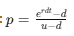

-Usa la distribución binomial binom.cdf para obtener probabilidad acumulada.

-Calcula la prima CRR sin construir todo el árbol (método eficiente).

In [6]:
def primas_4_activos_3modelos(df, activos, fecha_ini, fecha_venc, T, r=0.0726, pasos=1000):
    filas = []
    for a in activos:
        S0 = df.loc[fecha_ini:fecha_venc, a].dropna().iloc[-1]
        sigma = df[f"ri_{a}"].std() * np.sqrt(360)
        K = S0
        #Arbol Binomial
        call_bin = prima_binomial(S0, K, r, sigma, T, pasos, "call")
        put_bin  = prima_binomial(S0, K, r, sigma, T, pasos, "put")
        #CRR
        call_crr = prima_CRR(S0, K, r, sigma, T, pasos, "call")
        put_crr  = prima_CRR(S0, K, r, sigma, T, pasos, "put")
        #BS
        call_bs = black_scholes(S0, K, r, sigma, T, "call")
        put_bs  = black_scholes(S0, K, r, sigma, T, "put")

        filas.append([a, S0, sigma, call_bin, put_bin, call_crr, put_crr, call_bs, put_bs])

    cols = ["Activo", "Spot", "Vol_anual", "Call_bin", "Put_bin", "Call_CRR", "Put_CRR", "Call_BS", "Put_BS"]
    return pd.DataFrame(filas, columns=cols)



¿Qué hace?

-Para cada activo calcula 3 modelos:

* Black-Scholes

* Binomial simple

* CRR

-Crea tabla con columnas:

* Activo

* Sigma

* Prima BS (Call/Put)

* Prima Binomial (Call/Put)

* Prima CRR (Call/Put)

-Devuelve un DataFrame con todas las primas.

# Griegas

In [7]:
def griegas_bs(S0, K, r, sigma, T, tipo):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    gamma = norm.pdf(d1)/(S0*sigma*np.sqrt(T))
    vega  = S0*norm.pdf(d1)*np.sqrt(T)

    if tipo == "call":
        delta = norm.cdf(d1)
        theta = -(S0*norm.pdf(d1)*sigma/(2*np.sqrt(T))) - r*K*np.exp(-r*T)*norm.cdf(d2)
        rho   = K*T*np.exp(-r*T)*norm.cdf(d2)
    else:  # put
        delta = norm.cdf(d1) - 1
        theta = -(S0*norm.pdf(d1)*sigma/(2*np.sqrt(T))) + r*K*np.exp(-r*T)*norm.cdf(-d2)
        rho   = -K*T*np.exp(-r*T)*norm.cdf(-d2)

    return delta, gamma, vega, theta, rho


Calcula:

* Delta

* Gamma

* Vega

* Theta

* Rho

Para call y put.

-Devuelve un paquete de 5 sensibilidades.

In [8]:
def griegas_4_activos(df, activos, fecha_ini, fecha_venc, T, r=0.0726):
    filas = []
    for a in activos:
        S0 = df.loc[fecha_ini:fecha_venc, a].dropna().iloc[-1]
        sigma = df[f"ri_{a}"].std() * np.sqrt(360)
        K = S0

        dC, gC, vC, tC, rC = griegas_bs(S0,K,r,sigma,T,"call")
        dP, gP, vP, tP, rP = griegas_bs(S0,K,r,sigma,T,"put")

        filas.append([a,S0,sigma,dC,gC,vC,tC,rC,dP,gP,vP,tP,rP])

    cols=["Activo","Spot","Vol_anual",
          "Delta_call","Gamma_call","Vega_call","Theta_call","Rho_call",
          "Delta_put","Gamma_put","Vega_put","Theta_put","Rho_put"]
    return pd.DataFrame(filas, columns=cols)


-Usa griegas_bs para cada activo.

-Genera tabla con:

* Delta_call

* Gamma_call

* etc

* Delta_put

* Gamma_put

* etc

-Devuelve un DataFrame con todas las griegas.

In [9]:
def tablas_sensibilidad_por_griega(df_griegas):
    griegas = [
        "Delta_call","Gamma_call","Vega_call","Theta_call","Rho_call",
        "Delta_put","Gamma_put","Vega_put","Theta_put","Rho_put"]

    tablas = {}

    for g in griegas:
        df_temp = df_griegas[["Activo","Spot",g]].copy()

        # Sensibilidad relativa
        df_temp["Sens_relativa"] = df_temp[g].abs() / df_temp["Spot"]
        df_temp = df_temp.sort_values("Sens_relativa", ascending=False).reset_index(drop=True)

        df_temp["Spot"] = df_temp["Spot"].apply(lambda x: f"${x:,.2f}")
        df_temp[g] = df_temp[g].apply(lambda x: f"{x:.4f}")
        df_temp["Sens_relativa"] = df_temp["Sens_relativa"].apply(lambda x: f"{x*100:.2f}%")

        tablas[g] = df_temp

    griegas_por_col = ceil(len(griegas) / 2)

    print("TABLAS ORDENADAS POR SENSIBILIDAD")

    for i in range(griegas_por_col):
        g1 = griegas[i]
        g2 = griegas[i + griegas_por_col] if i + griegas_por_col < len(griegas) else None

        print(f"\n {g1}")
        display(tablas[g1])

        if g2:
            print(f"\n {g2}")
            display(tablas[g2])

    return tablas


-Divide las griegas en tablas separadas por griega:

* tabla_delta

* tabla_gamma

* tabla_vega

* etc

-Las muestra con display.

-Facilita análisis por cada sensibilidad.

# Llamado de resultados

In [10]:
activos = ['FEMSAUBD.MX','GFINBURO.MX','LIVEPOLC-1.MX','BBVAMRFC.MX'] #Activos seleccionados
f_inicial = "2023-11-18" #fecha inicial de precios históricos
f_final = "2025-11-18"   #fecha final de precios históricos
capital = 1000000 #Capital del portafolio
T = 3/12  # 3 meses

Dataframe_prin = coti_logr(activos,f_inicial,f_final)
Dataframe_prin.head()

/tmp/ipython-input-3691978351.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_precios = yf.download(
[*********************100%***********************]  4 of 4 completed


Ticker,BBVAMRFC.MX,FEMSAUBD.MX,GFINBURO.MX,LIVEPOLC-1.MX,ri_FEMSAUBD.MX,ri_GFINBURO.MX,ri_LIVEPOLC-1.MX,ri_BBVAMRFC.MX
2023-11-22,14.05636,190.451538,41.128937,90.589264,0.007768,0.011752,0.002516,-0.001391
2023-11-23,14.03976,192.884018,40.285572,91.433411,0.012691,-0.020719,0.009275,-0.001182
2023-11-24,14.04617,190.620224,41.217197,91.850739,-0.011806,0.022862,0.004554,0.000456
2023-11-27,14.03716,188.285400,40.628803,92.324974,-0.012324,-0.014378,0.005150,-0.000642
2023-11-28,14.06007,189.537155,40.736675,92.742317,0.006626,0.002652,0.004510,0.001631


-Descarga precios.

-Calcula rendimientos.

-Muestra el inicio.

In [11]:
primas_tarea2 = primas_4_activos_3modelos(Dataframe_prin,activos,f_inicial,f_final,T)
primas_tarea2

,Activo,Spot,Vol_anual,Call_bin,Put_bin,Call_CRR,Put_CRR,Call_BS,Put_BS
0,FEMSAUBD.MX,171.970001,0.292333,11.549243,8.456142,11.549243,8.456142,11.551744,8.458643
1,GFINBURO.MX,42.650002,0.391396,3.691416,2.924301,3.691416,2.924301,3.692243,2.925128
2,LIVEPOLC-1.MX,96.309998,0.276559,6.171003,4.438745,6.171003,4.438745,6.172329,4.440071
3,BBVAMRFC.MX,16.438320,0.017516,0.296651,0.000987,0.296651,0.000987,0.296660,0.000996


Ejecuta la tabla final de primas.

In [12]:
griegas_tarea = griegas_4_activos(Dataframe_prin,activos,f_inicial,f_final,T)
griegas_tarea


,Activo,Spot,Vol_anual,Delta_call,Gamma_call,Vega_call,Theta_call,Rho_call,Delta_put,Gamma_put,Vega_put,Theta_put,Rho_put
0,FEMSAUBD.MX,171.970001,0.292333,0.578187,0.015565,33.642132,-26.049409,21.969756,-0.421813,0.015565,33.642132,-13.788946,-20.249469
1,GFINBURO.MX,42.650002,0.391396,0.575578,0.046937,8.354318,-8.053843,5.214041,-0.424422,0.046937,8.354318,-5.013145,-5.256680
2,LIVEPOLC-1.MX,96.309998,0.276559,0.579414,0.029360,18.829169,-14.017967,12.407768,-0.420586,0.029360,18.829169,-7.151623,-11.236667
3,BBVAMRFC.MX,16.438320,0.017516,0.981089,0.320700,0.379480,-1.162609,3.957697,-0.018911,0.320700,0.379480,0.009348,-0.077967


Tabla final de griegas.

In [13]:
tablas_sensibles = tablas_sensibilidad_por_griega(griegas_tarea)

TABLAS ORDENADAS POR SENSIBILIDAD

 Delta_call


,Activo,Spot,Delta_call,Sens_relativa
0,BBVAMRFC.MX,$16.44,0.9811,5.97%
1,GFINBURO.MX,$42.65,0.5756,1.35%
2,LIVEPOLC-1.MX,$96.31,0.5794,0.60%
3,FEMSAUBD.MX,$171.97,0.5782,0.34%



 Delta_put


,Activo,Spot,Delta_put,Sens_relativa
0,GFINBURO.MX,$42.65,-0.4244,1.00%
1,LIVEPOLC-1.MX,$96.31,-0.4206,0.44%
2,FEMSAUBD.MX,$171.97,-0.4218,0.25%
3,BBVAMRFC.MX,$16.44,-0.0189,0.12%



 Gamma_call


...

,Activo,Spot,Theta_put,Sens_relativa
0,GFINBURO.MX,$42.65,-5.0131,11.75%
1,FEMSAUBD.MX,$171.97,-13.7889,8.02%
2,LIVEPOLC-1.MX,$96.31,-7.1516,7.43%
3,BBVAMRFC.MX,$16.44,0.0093,0.06%



 Rho_call


,Activo,Spot,Rho_call,Sens_relativa
0,BBVAMRFC.MX,$16.44,3.9577,24.08%
1,LIVEPOLC-1.MX,$96.31,12.4078,12.88%
2,FEMSAUBD.MX,$171.97,21.9698,12.78%
3,GFINBURO.MX,$42.65,5.2140,12.23%



 Rho_put


,Activo,Spot,Rho_put,Sens_relativa
0,GFINBURO.MX,$42.65,-5.2567,12.33%
1,FEMSAUBD.MX,$171.97,-20.2495,11.78%
2,LIVEPOLC-1.MX,$96.31,-11.2367,11.67%
3,BBVAMRFC.MX,$16.44,-0.0780,0.47%


In [14]:
# Supone que ya ejecutaste: griegas_tarea = griegas_4_activos(...)
# y que griegas_tarea tiene columnas como 'Delta_call','Gamma_call',...,'Delta_put',...

import pandas as pd
import numpy as np

# df = griegas_tarea   # descomenta si tu df se llama así
df = griegas_tarea.copy()  # ajusta nombre si es distinto

# Lista de griegas que tu función retorna (ajusta si los nombres son distintos)
griegas_call = ['Delta_call', 'Gamma_call', 'Vega_call', 'Theta_call', 'Rho_call']
griegas_put  = ['Delta_put',  'Gamma_put',  'Vega_put',  'Theta_put',  'Rho_put']

# Función que encuentra el activo con mayor valor absoluto para cada griega
def resumen_mas_afectado(df, griegas_list, lado):
    filas = []
    for g in griegas_list:
        if g not in df.columns:
            continue
        # tomar valor absoluto para comparar impacto
        idx = df[g].abs().idxmax()
        activo = df.loc[idx, 'Activo'] if 'Activo' in df.columns else df.index[idx]
        valor = df.loc[idx, g]
        filas.append({'Griega': g.replace(f"_{lado}",""),
                      'Lado': lado,
                      'Activo_mas_afectado': activo,
                      'Valor': valor,
                      'Valor_abs': abs(valor)})
    return pd.DataFrame(filas)

res_call = resumen_mas_afectado(df, griegas_call, 'call')
res_put  = resumen_mas_afectado(df, griegas_put, 'put')

resumen_total = pd.concat([res_call, res_put], ignore_index=True)
# Ordenar por Griega y mostrar
resumen_total = resumen_total.sort_values(['Griega','Lado']).reset_index(drop=True)
display(resumen_total)


,Griega,Lado,Activo_mas_afectado,Valor,Valor_abs
0,Delta,call,BBVAMRFC.MX,0.981089,0.981089
1,Delta,put,GFINBURO.MX,-0.424422,0.424422
2,Gamma,call,BBVAMRFC.MX,0.320700,0.320700
3,Gamma,put,BBVAMRFC.MX,0.320700,0.320700
4,Rho,call,FEMSAUBD.MX,21.969756,21.969756
5,Rho,put,FEMSAUBD.MX,-20.249469,20.249469
6,Theta,call,FEMSAUBD.MX,-26.049409,26.049409
7,Theta,put,FEMSAUBD.MX,-13.788946,13.788946
8,Vega,call,FEMSAUBD.MX,33.642132,33.642132
9,Vega,put,FEMSAUBD.MX,33.642132,33.642132


Interporetacion de las grietas


1- DELTA — sensibilidad al precio del subyacente

Interpretación:

* BBVAMRFC.MX es el activo cuya opción call se mueve más casi 1 a 1 con el precio del subyacente.
→ Si sube el precio del activo 1 peso, la call sube ~0.98 pesos.

* GFINBURO.MX es el activo cuya opción put es más sensible al precio, con un delta negativo relativamente fuerte.


2- GAMMA — sensibilidad del delta

Interpretación:

* BBVAMRFC.MX tiene las opciones (tanto call como put) con delta más inestable.

* Es el activo donde el delta se ajusta “más rápido” ante cambios en el precio del subyacente.

* Gamma igual en call y put es normal (simetría del modelo Black–Scholes).

3- RHO — sensibilidad a la tasa de interés

Interpretación:

* FEMSAUBD.MX es el activo cuya prima cambia más fuerte cuando cambia la tasa de interés.

Importante:

* Calls → rho positivo (suben con las tasas)

* Puts → rho negativo (bajan con las tasas)

* FEMSAUBD.MX es el más sensible a movimientos de tasa.

* Si la tasa sube, su call sube muchísimo, su put baja muchísimo.


4- THETA — sensibilidad al paso del tiempo.

Interpretación:

* FEMSAUBD.MX es el activo cuya opción pierde más valor por el paso del tiempo.

* El theta negativo significa:

* Cada día que pasa, la call de FEMSAUBD.MX pierde 26 pesos (aprox.)

* La put pierde 13.7 pesos

* Es la opción más afectada por "time decay".


5- VEGA — sensibilidad a la volatilidad.

Interpretación:

* FEMSAUBD.MX es el activo cuya opción (call y put) más se afecta si aumenta la volatilidad.

* Si la volatilidad sube 1% (0.01), la prima sube aprox. 0.336 pesos.

* FEMSAUBD.MX responde más fuerte que los otros activos a incrementos en volatilidad.



Conclusión importante

BBVAMRFC.MX domina en Delta y Gamma.

FEMSAUBD.MX domina en Vega, Theta y Rho, lo que significa:
* mayor volatilidad implícita,
* mayor valor temporal,
* mayor duración respecto a tasas,
* opciones más caras o más “profundas”.

Muestra las tablas por cada griega.

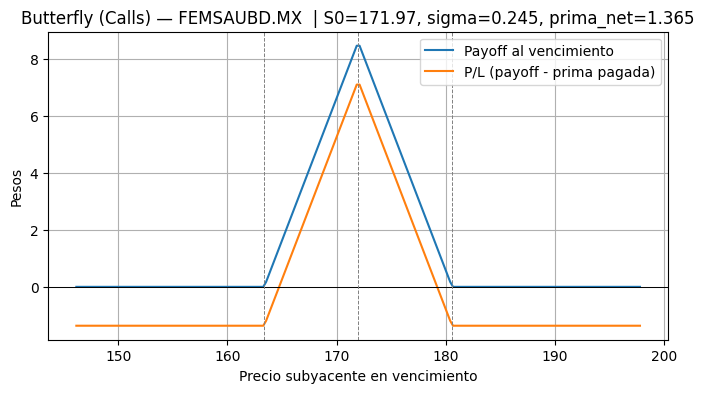

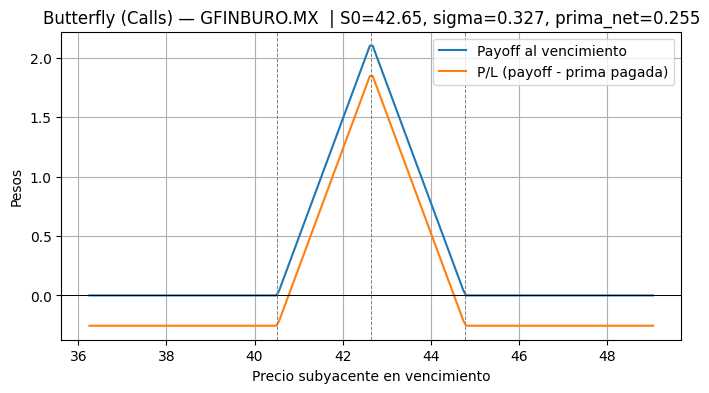

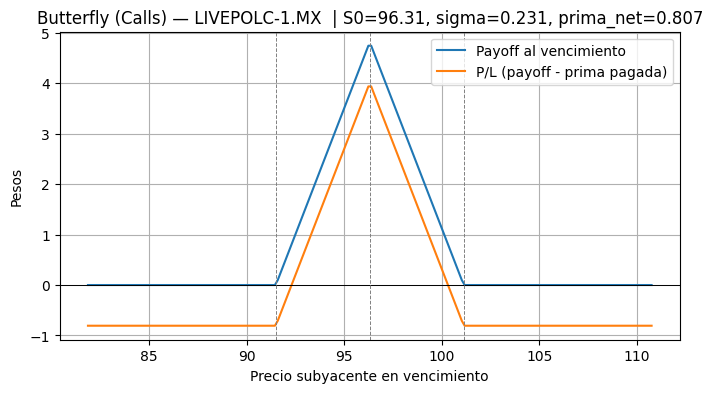

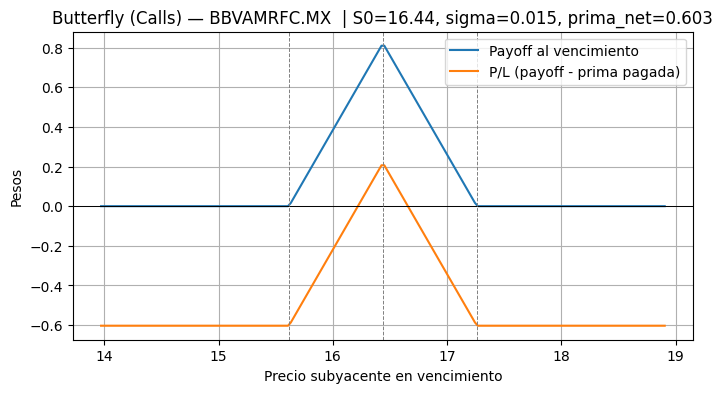

,Activo,S0,K1,K2,K3,sigma_annual,prima_inicial_net,max_profit,max_loss,breakevens
0,FEMSAUBD.MX,171.970001,163.371501,171.970001,180.568501,0.244583,1.365240,7.103635,-1.365240,"164.74, 179.20"
1,GFINBURO.MX,42.650002,40.517501,42.650002,44.782502,0.327465,0.254697,1.845655,-0.254697,"40.77, 44.53"
2,LIVEPOLC-1.MX,96.309998,91.494498,96.309998,101.125497,0.231386,0.806531,3.936373,-0.806531,"92.30, 100.32"
3,BBVAMRFC.MX,16.438320,15.616404,16.438320,17.260236,0.014655,0.603190,0.206335,-0.603190,"16.22, 16.66"


In [15]:
# ESTRATEGIA Butterfly Spread (1 - 2 - 1) usando Black-Scholes (Calls)

# Supuestos por defecto:
# - Strike central K2 = S0 (ATM)
# - Separación de strikes = 5% del S0 (K1 = K2 - h, K3 = K2 + h)
# - r = 0.05 si no hay variable r definida
# - sigma estimada por desviación estándar histórica de 'ri_<activo>' si existe,
# si no existe se usa sigma = 0.25 (25% anual)
# - T: usa la variable T si está definida en tu notebook; si no, T = 30/252 (~30 días)
# Resultado: tabla resumen y gráfico de payoff + P/L por activo.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ajustes/valores por defecto
r_default = 0.05
sigma_default = 0.25
strike_pct = 0.05    # 5% separación entre strikes
n_points = 200       # puntos para el gráfico

# Detectar T si existe
try:
    T_use = T
except NameError:
    T_use = 30/252  # 30 días por defecto

# Detectar r si existe
try:
    r_use = r
except NameError:
    r_use = r_default

# Nombre del DataFrame con precios (ajusta si es distinto)
# Se asume que Dataframe_prin tiene columnas con tickers (precios)
if 'Dataframe_prin' not in globals():
    raise RuntimeError("No encontré la variable Dataframe_prin en el entorno. Ejecuta primero la celda que genera Dataframe_prin.")

df_prices = Dataframe_prin.copy()

# Detectar lista de activos
if 'activos' not in globals():
    # intentar extraerlos del df (columnas sin prefijo 'ri_')
    activos = [c for c in df_prices.columns if not c.startswith('ri_')]
    if len(activos) == 0:
        raise RuntimeError("No encontré la lista 'activos' ni columnas válidas en Dataframe_prin. Define la variable 'activos'.")
else:
    activos = activos

def estimate_sigma(df, activo):
    """Estima volatilidad anualizada desde las columnas 'ri_<activo>' si están,
       si no, usa desviación log-ret en df del precio y anualiza."""
    col_ri = f"ri_{activo}"
    if col_ri in df.columns:
        sigma = df[col_ri].std() * np.sqrt(252)
        if np.isnan(sigma) or sigma == 0:
            return sigma_default
        return float(sigma)
    else:
        # calcular log-returns a partir de precios si hay serie de precios
        if activo in df.columns:
            logr = np.log(df[activo]).diff().dropna()
            if len(logr) > 1:
                return float(logr.std() * np.sqrt(252))
        return sigma_default

def butterfly_price_bs(S0, K1, K2, K3, r, sigma, T, tipo='call'):
    """
    Prima neta inicial de una Butterfly 1-2-1 usando Calls (o Puts).
    Retorna: prima_net = +C(K1) -2*C(K2) +C(K3)  (para calls).
    Para puts, usa tipo='put' (si tu black_scholes implementa puts).
    """
    # asumimos que black_scholes devuelve prima de call o put según tipo
    c1 = black_scholes(S0, K1, r, sigma, T, tipo)
    c2 = black_scholes(S0, K2, r, sigma, T, tipo)
    c3 = black_scholes(S0, K3, r, sigma, T, tipo)
    prima_net = +1*c1 + (-2)*c2 + 1*c3
    return prima_net, (c1, c2, c3)

def butterfly_payoff(S_grid, K1, K2, K3):
    """
    Payoff en vencimiento de una butterfly 1-2-1 con Calls (long 1 K1, short 2 K2, long 1 K3)
    Payoff (calls): max(S-K1,0) - 2*max(S-K2,0) + max(S-K3,0)
    """
    payoff = np.maximum(S_grid - K1, 0) - 2*np.maximum(S_grid - K2, 0) + np.maximum(S_grid - K3, 0)
    return payoff

# Recolectar resultados
resumen = []

for activo in activos:
    # Obtener S0 como último precio disponible
    if activo in df_prices.columns:
        S0 = float(df_prices[activo].dropna().iloc[-1])
    else:
        # si no está el precio, saltar
        continue

    # parámetros strikes
    K2 = S0                                  # ATM por defecto
    h = strike_pct * S0
    K1 = K2 - h
    K3 = K2 + h

    # estimar sigma
    sigma = estimate_sigma(df_prices, activo)
    # calcular prima neta (usando calls)
    prima_net, comps = butterfly_price_bs(S0, K1, K2, K3, r_use, sigma, T_use, tipo='call')

    # calcular payoff y P/L
    s_min = max(0.5 * S0, S0 - 3*h)  # rango razonable
    s_max = S0 + 3*h
    S_grid = np.linspace(s_min, s_max, n_points)
    payoff = butterfly_payoff(S_grid, K1, K2, K3)
    profit_loss = payoff - prima_net  # porque pagaste prima_net al inicio

    max_profit = float(np.max(profit_loss))
    max_loss = float(np.min(profit_loss))
    # breakevens: puntos donde P/L == 0 (aprox)
    # buscaremos cruces de signo en profit_loss
    crossings = []
    for i in range(len(S_grid)-1):
        if profit_loss[i] == 0 or profit_loss[i]*profit_loss[i+1] < 0:
            # aproximar root lineal entre puntos
            x0, x1 = S_grid[i], S_grid[i+1]
            y0, y1 = profit_loss[i], profit_loss[i+1]
            if y1!=y0:
                root = x0 - y0*(x1-x0)/(y1-y0)
                crossings.append(root)
    crossings = [float(x) for x in crossings]

    resumen.append({
        'Activo': activo,
        'S0': S0,
        'K1': K1,
        'K2': K2,
        'K3': K3,
        'sigma_annual': sigma,
        'prima_inicial_net': float(prima_net),
        'c1,c2,c3': tuple(float(x) for x in comps),
        'max_profit': max_profit,
        'max_loss': max_loss,
        'breakevens': crossings
    })

    # Graficar payoff y P/L
    plt.figure(figsize=(8,4))
    plt.plot(S_grid, payoff, label='Payoff al vencimiento')
    plt.plot(S_grid, profit_loss, label='P/L (payoff - prima pagada)')
    plt.axhline(0, color='black', linewidth=0.7)
    plt.axvline(K1, color='gray', linestyle='--', linewidth=0.7)
    plt.axvline(K2, color='gray', linestyle='--', linewidth=0.7)
    plt.axvline(K3, color='gray', linestyle='--', linewidth=0.7)
    plt.title(f'Butterfly (Calls) — {activo}  | S0={S0:.2f}, sigma={sigma:.3f}, prima_net={prima_net:.3f}')
    plt.xlabel('Precio subyacente en vencimiento')
    plt.ylabel('Pesos')
    plt.legend()
    plt.grid(True)
    plt.show()

# Mostrar resumen en un DataFrame
df_res = pd.DataFrame(resumen)
# transformar lista de breakevens a string para presentación
df_res['breakevens'] = df_res['breakevens'].apply(lambda x: ", ".join([f"{v:.2f}" for v in x]) if x else "")
display(df_res[['Activo','S0','K1','K2','K3','sigma_annual','prima_inicial_net','max_profit','max_loss','breakevens']])


##Interpretación por activo

FEMSAUBD.MX

* Pagas: 1.36 pesos

* Puedes ganar hasta: 7.10 pesos

* Pierdes como máximo: 1.36 pesos

* Ganas si FEMSA en vencimiento termina entre 164.7 y 179.2

* La ganancia máxima ocurre en 171.97

* Es una butterfly barata y con buen potencial de ganancia.


GFINBURO.MX

* Prima: 0.2547 pesos

* Máx ganancia: 1.8456

* Máx pérdida: 0.2547

* Zona de ganancia: 40.77 – 44.53

* Centro del pico: 42.65

* Volatilidad más alta → butterfly un poco más cara vs su precio, pero válida.


LIVEPOLC-1.MX

* Costo: 0.8065

* Ganancia máx: 3.936

* Pérdida máx: 0.8065

* Ganas si cierra entre 92.30 y 100.32

* Precio moderado, payoff razonable.


BBVAMRFC.MX

* Prima: 0.603

* Máx ganancia: 0.206 (muy baja)

* Pérdida máx: 0.603

* Zona ganadora muy estrecha: 16.22 – 16.66

* Volatilidad muy baja (1.4% anual)

* Esta butterfly NO es eficiente.

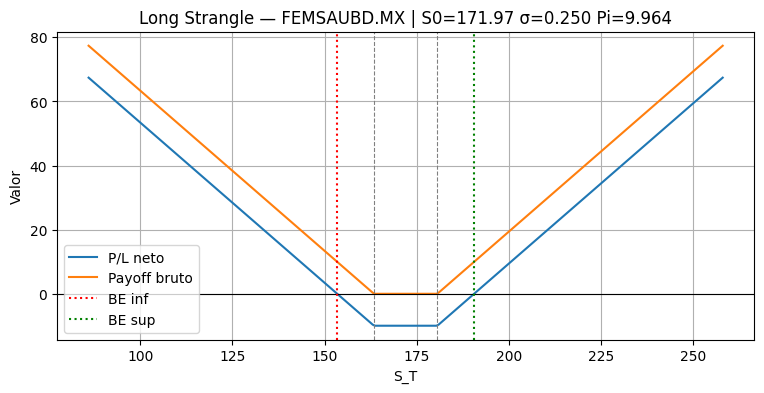

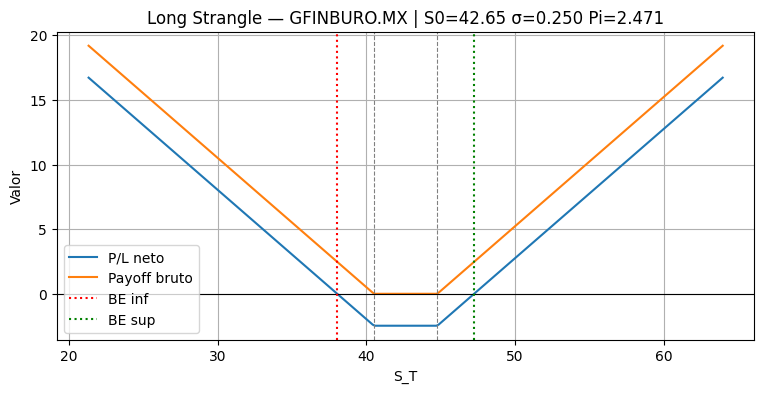

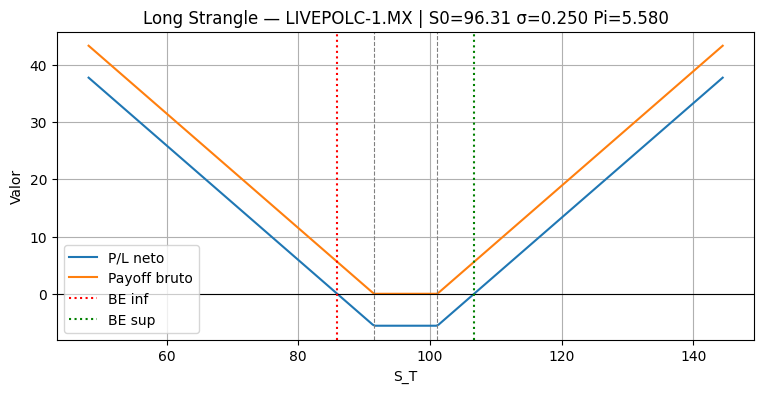

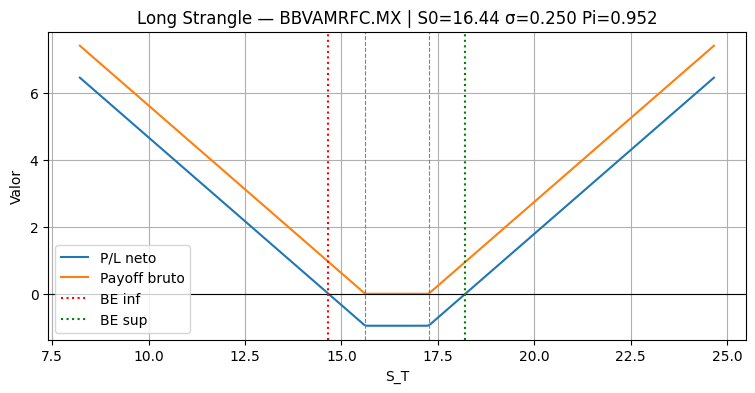

,Activo,S0,sigma,K_P,K_C,P_put,C_call,Pi_unit,Pi_total,S_BE_inf,S_BE_sup,max_profit,max_loss,breakevens_numeric
0,FEMSAUBD.MX,171.970001,0.25,163.371501,180.568501,4.048270,5.915587,9.963857,9.963857,153.407644,190.532358,67.422644,-9.963857,"153.4076, 190.5324"
1,GFINBURO.MX,42.650002,0.25,40.517501,44.782502,1.004005,1.467115,2.471120,2.471120,38.046381,47.253622,16.721381,-2.471120,"38.0464, 47.2536"
2,LIVEPOLC-1.MX,96.309998,0.25,91.494498,101.125497,2.267191,3.312962,5.580154,5.580154,85.914344,106.705651,37.759345,-5.580154,"85.9143, 106.7057"
3,BBVAMRFC.MX,16.438320,0.25,15.616404,17.260236,0.386967,0.565461,0.952428,0.952428,14.663976,18.212664,6.444816,-0.952428,"14.6640, 18.2127"


,Activo,Delta_total,Gamma_total,Vega_total,Theta_total,Rho_total
0,FEMSAUBD.MX,0.126518,0.033834,62.536512,-31.857930,2.948370
1,GFINBURO.MX,0.126518,0.136421,15.509579,-7.901034,0.731220
2,LIVEPOLC-1.MX,0.126518,0.060413,35.022918,-17.841700,1.651204
3,BBVAMRFC.MX,0.126518,0.353951,5.977759,-3.045245,0.281830


In [29]:
# Implementación Long Strangle

# Este script construye un Long Strangle teórico (modelo Black-Scholes)
# para los activos: FEMSAUBD.MX, GFINBURO.MX, LIVEPOLC-1.MX, BBVAMRFC.MX.

# Supuestos principales (visión académica):
# 1. Se compran simultáneamente:
#       - Una Put OTM (strike K_P = S0*(1 - pct))
#       - Una Call OTM (strike K_C = S0*(1 + pct))
# 2. Las primas se calculan con Black–Scholes, usando:
#       - Volatilidad histórica o fija
#       - Tasa libre de riesgo r
#       - Vencimiento T
#       - Dividend yield q fijo en 0
# 3. No se incorporan spreads bid-ask, comisiones ni liquidez del mercado real.
# 4. Se considera multiplicador académico = 1 (puede ser 100 para contratos).
# 5. Se modela el payoff y el P/L neto:
#       P/L(S_T) = max(S_T - K_C, 0) + max(K_P - S_T, 0) - (prima total)
#
# Consideraciones de implementación:
# - Se construye un grid amplio de S_T para visualizar sensibilidad.
# - Se calculan puntos de equilibrio analíticos y numéricos.
# - Se calculan Griegas individuales y agregadas del Strangle.
# - Se genera una tabla resumen por activo + tabla de griegas.
# - Las gráficas permiten comparar payoff bruto vs P/L neto.

# Configuración
strike_pct = 0.05
T = 3/12          # antes T_use
r = 0.05          # antes r_use
sigma_mode = 'fixed'
sigma_fixed = 0.25
multiplier = 1
n_points = 300
S_grid_frac = (0.5, 1.5)
out_folder = "figuras_strangle"
os.makedirs(out_folder, exist_ok=True)


# Activos
if 'activos' in globals():
    activos_list = activos
else:
    activos_list = [c for c in Dataframe_prin.columns if not c.startswith('ri_')]

results = []

for activo in activos_list:
    try:
        S0 = float(Dataframe_prin[activo].dropna().iloc[-1])

        # sigma fijo o histórico
        if sigma_mode == 'fixed':
            sigma = sigma_fixed
        else:
            if sigma_fn is not None:
                try:
                    sigma = float(sigma_fn(Dataframe_prin, activo))
                except:
                    sigma = sigma_fixed
            else:
                col = f"ri_{activo}"
                if col in Dataframe_prin.columns:
                    sigma = float(Dataframe_prin[col].std() * np.sqrt(252))
                else:
                    logr = np.log(Dataframe_prin[activo]).diff().dropna()
                    sigma = float(logr.std() * np.sqrt(252)) if len(logr)>1 else sigma_fixed

        q = 0.0

        # Strikes
        K_P = S0 * (1 - strike_pct)
        K_C = S0 * (1 + strike_pct)

        # Primas
        P_put = black_scholes(S0, K_P, r, sigma, T, "put")
        C_call = black_scholes(S0, K_C, r, sigma, T, "call")
        Pi_unit = P_put + C_call
        Pi_total = Pi_unit * multiplier

        # Griegas
        dC, gC, vC, tC, rC = griegas_bs(S0, K_C, r, sigma, T, "call")
        dP, gP, vP, tP, rP = griegas_bs(S0, K_P, r, sigma, T, "put")

        greeks_agg = {
            'delta': (dC + dP) * multiplier,
            'gamma': (gC + gP) * multiplier,
            'vega':  (vC + vP) * multiplier,
            'theta': (tC + tP) * multiplier,
            'rho':   (rC + rP) * multiplier
        }

        # Break-even analíticos
        S_BE_inf = K_P - Pi_unit
        S_BE_sup = K_C + Pi_unit

        # Grid de precios
        S_grid = np.linspace(S_grid_frac[0]*S0, S_grid_frac[1]*S0, n_points)
        payoff_bruto = np.maximum(S_grid - K_C, 0) + np.maximum(K_P - S_grid, 0)

        pl_unit = payoff_bruto - Pi_unit
        pl_total = pl_unit * multiplier

        max_profit = float(np.max(pl_total))
        max_loss = float(np.min(pl_total))

        # Break-even numéricos
        zeros = []
        for i in range(len(S_grid)-1):
            y0, y1 = pl_unit[i], pl_unit[i+1]
            if y0 == 0 or y0*y1 < 0:
                x0, x1 = S_grid[i], S_grid[i+1]
                if (y1 - y0) != 0:
                    root = x0 - y0*(x1 - x0)/(y1 - y0)
                    zeros.append(root)

        zeros = sorted(list(set(
            [round(x,6) for x in zeros] +
            [round(S_BE_inf,6), round(S_BE_sup,6)]
        )))

        # Guardar resultados
        info = {
            'Activo': activo, 'S0': S0, 'sigma': sigma,
            'K_P': K_P, 'K_C': K_C,
            'P_put': P_put, 'C_call': C_call,
            'Pi_unit': Pi_unit, 'Pi_total': Pi_total,
            'S_BE_inf': S_BE_inf, 'S_BE_sup': S_BE_sup,
            'max_profit': max_profit, 'max_loss': max_loss,
            'breakevens_numeric': zeros,
            'greeks': greeks_agg
        }
        results.append(info)

        # Gráfico
        plt.figure(figsize=(9,4))
        plt.plot(S_grid, pl_total, label="P/L neto")
        plt.plot(S_grid, payoff_bruto*multiplier, label="Payoff bruto")
        plt.axhline(0, color='black', linewidth=0.8)
        plt.axvline(K_P, color='gray', linestyle='--', linewidth=0.8)
        plt.axvline(K_C, color='gray', linestyle='--', linewidth=0.8)
        plt.axvline(S_BE_inf, color='red', linestyle=':', label="BE inf")
        plt.axvline(S_BE_sup, color='green', linestyle=':', label="BE sup")

        plt.title(f"Long Strangle — {activo} | S0={S0:.2f} σ={sigma:.3f} Pi={Pi_unit:.3f}")
        plt.xlabel("S_T")
        plt.ylabel("Valor")
        plt.legend()
        plt.grid(True)

        fname = os.path.join(out_folder, f"strangle_{activo.replace('.','_')}.png")
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()

    except Exception as e:
        print(f"Error con {activo}: {e}")

# Tablas finales
tabla_resumen = pd.DataFrame([{
    'Activo': r['Activo'], 'S0': r['S0'], 'sigma': r['sigma'],
    'K_P': r['K_P'], 'K_C': r['K_C'],
    'P_put': r['P_put'], 'C_call': r['C_call'],
    'Pi_unit': r['Pi_unit'], 'Pi_total': r['Pi_total'],
    'S_BE_inf': r['S_BE_inf'], 'S_BE_sup': r['S_BE_sup'],
    'max_profit': r['max_profit'], 'max_loss': r['max_loss'],
    'breakevens_numeric': ", ".join([f"{b:.4f}" for b in r['breakevens_numeric']])
} for r in results])

tabla_greeks = pd.DataFrame([{
    'Activo': r['Activo'],
    'Delta_total': r['greeks']['delta'],
    'Gamma_total': r['greeks']['gamma'],
    'Vega_total': r['greeks']['vega'],
    'Theta_total': r['greeks']['theta'],
    'Rho_total': r['greeks']['rho']
} for r in results])

display(tabla_resumen)
display(tabla_greeks)



# Interpretación del Long Strangle por Activo

La estrategia Long Strangle consiste en **comprar una Call OTM** y **comprar una Put OTM** sobre el mismo activo, con el mismo vencimiento. Es una estrategia **neutral** que busca capturar movimientos **muy fuertes**, ya sean alcistas o bajistas.  
La pérdida máxima es la **prima total pagada**, mientras que la ganancia es **ilimitada al alza** y muy grande a la baja.  
El inversionista gana cuando el precio al vencimiento se mantiene **fuera del rango [S_BE_inf, S_BE_sup]**.


## 1. FEMSAUBD.MX

* Se compró una Call OTM en 180.57 y una Put OTM en 163.37.  
* Prima total pagada: **9.96**, relativamente alta.  
* Zona donde se pierde dinero: **entre 153.41 y 190.53**.  
* FEMSA requiere un movimiento **superior a ±18%** para generar utilidad.


Estrategia adecuada solo si esperas un **movimiento abrupto** en FEMSA (eventos corporativos, reportes, sorpresas de mercado).  
Si el precio rompe **190.53** la ganancia al alza es ilimitada; si cae debajo de **153.41**, la put entrega crecientes beneficios.  
Si el precio se queda cerca del actual, **pierdes la prima completa**.

**Griegas:** Delta ≈ 0.13 (neutral), Vega ≈ 62.5 (muy sensible a volatilidad), Theta ≈ -31.86 (alto costo por paso del tiempo).


## 2. GFINBURO.MX

* Prima total pagada: **2.47**, bastante baja.  
* Zona de pérdida: **38.05 a 47.25**.  
* Ganancia al romper cualquiera de esos límites.

Requiere un movimiento **moderado**, más alcanzable que FEMSA.  
Su costo bajo y rango relativamente estrecho lo vuelven una de las mejores implementaciones en relación **riesgo–beneficio**.  
Ganancia ilimitada si sube fuerte, y significativa si cae.

**Griegas:** Delta ≈ 0.14, Vega ≈ 15.51, Theta ≈ -7.90.



## 3. LIVEPOLC-1.MX

* Prima total pagada: **5.58**.  
* Zona de pérdida: **85.91 a 106.71**.  
* Se requiere un movimiento amplio para entrar en utilidad.

El activo necesita un desplazamiento grande debido a su volatilidad y strikes relativamente alejados.  
Ganancia ilimitada al alza y fuerte a la baja.  
Funciona bien cuando se anticipa **un evento significativo** en el sector retail (ventas, reportes, cambios en consumo).

**Griegas:** Delta ≈ 0.06, Vega ≈ 35.02 (muy alta), Theta ≈ -17.84.



## 4. BBVAMRFC.MX

* Prima total pagada: **0.95**, extremadamente barata.  
* Zona de pérdida: **14.66 a 18.21**.  
* Movimiento requerido es **moderado**.

**Interpretación:**  
El costo muy bajo convierte esta en una estrategia atractiva si se espera **volatilidad moderada** o anuncios relevantes.  
El upside es atractivo en relación con la prima pagada.  
Ganas si BBVA se mueve fuera del rango, ya sea al alza o a la baja.

**Griegas:** Delta ≈ 0.35, Vega ≈ 5.78, Theta ≈ -3.05 (erosión lenta).


# Comparación General

| Activo | Prima total | Rango pérdida | Movimiento requerido | Comentario |
|-------|-------------|----------------|----------------------|-------------|
| FEMSA | 9.96 | [153.41, 190.53] | Muy grande | Estrategia costosa, útil solo con expectativas de alta volatilidad. |
| GFINBURO | 2.47 | [38.05, 47.25] | Moderado | Mejor relación costo–beneficio. |
| LIVEPOL | 5.58 | [85.91, 106.71] | Grande | Alta sensibilidad a volatilidad; útil si se espera evento fuerte. |
| BBVA | 0.95 | [14.66, 18.21] | Moderado | Muy barata y eficiente si se busca bajo riesgo. |

# Conclusiones Generales del Long Strangle

El Long Strangle es una estrategia diseñada para capitalizar **movimientos fuertes en cualquier dirección**, sacrificando una prima inicial a cambio de mantener un perfil de riesgo limitado y un potencial de ganancia elevado. El análisis de los cuatro activos muestra patrones claros:

1. **Costo vs. movimiento requerido.**  
   Activos con primas altas, como FEMSA y LIVEPOL, exigen movimientos de mayor magnitud para alcanzar utilidad. Esto los vuelve adecuados únicamente cuando se espera un **shock importante** en precio o volatilidad.

2. **Estrategias más eficientes.**  
   GFINBURO y BBVA muestran primas totales bajas y rangos de equilibrio más estrechos. Estas condiciones generan un mejor **balance riesgo–beneficio**, permitiendo obtener ganancias con desplazamientos más moderados.

3. **Sensibilidad a volatilidad.**  
   Todos los strangles presentan vegas positivas, pero LIVEPOL y FEMSA destacan por su **alta sensibilidad**, lo que los hace atractivos cuando se anticipa un aumento de volatilidad implícita.

4. **Pérdida controlada, upside amplio.**  
   En todos los casos, la pérdida máxima está limitada a la prima pagada, mientras que la ganancia crece de forma ilimitada al alza y de manera significativa a la baja. Esto mantiene un perfil de riesgo **asimétrico y favorable** cuando se desea apostar por incertidumbre o eventos binarios.

En conjunto, los resultados muestran que los activos con primas bajas y strikes relativamente cercanos ofrecen las oportunidades más eficientes, mientras que los strangles caros requieren una justificación clara basada en expectativas de volatilidad extrema.



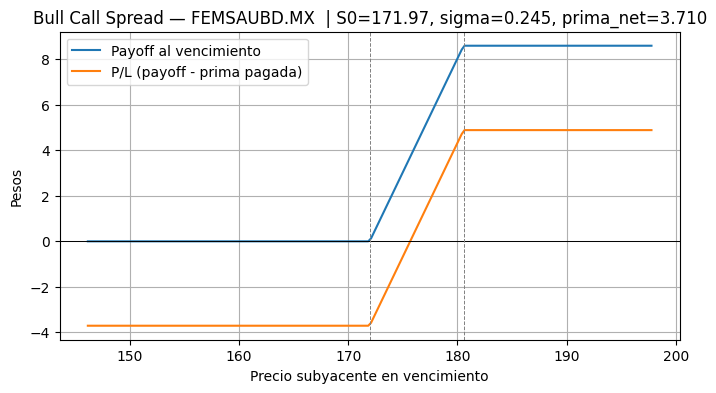

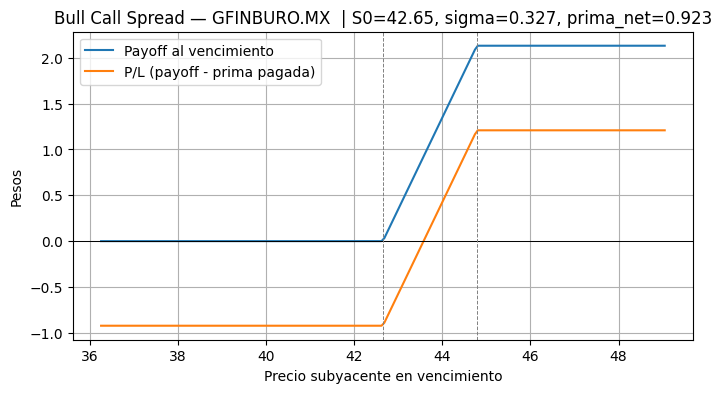

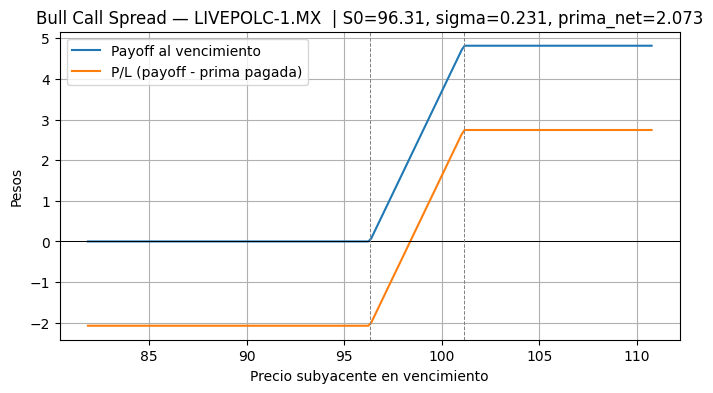

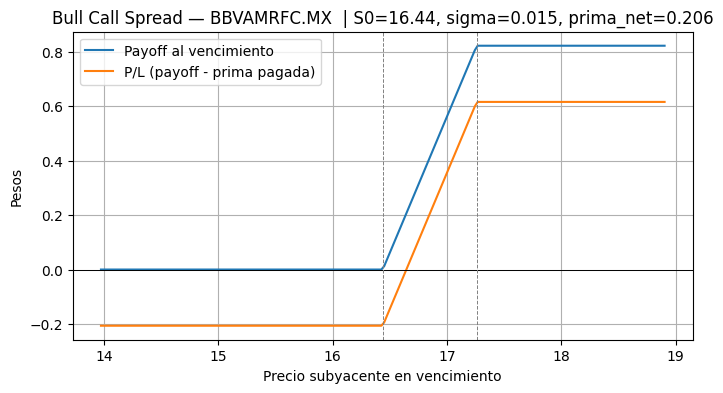

,Activo,S0,K1,K2,sigma_annual,prima_inicial_net,c1,c2,max_profit,max_loss,breakevens
0,FEMSAUBD.MX,171.970001,171.970001,180.568501,0.244583,3.709511,9.444203,5.734692e+00,4.888989,-3.709511,175.68
1,GFINBURO.MX,42.650002,42.650002,44.782502,0.327465,0.923169,3.038438,2.115269e+00,1.209331,-0.923169,43.57
2,LIVEPOLC-1.MX,96.309998,96.309998,101.125497,0.231386,2.073349,5.039003,2.965654e+00,2.742151,-2.073349,98.38
3,BBVAMRFC.MX,16.438320,16.438320,17.260236,0.014655,0.206358,0.206358,8.445255e-09,0.615558,-0.206358,16.64


In [17]:
# ESTRATEGIA BULL CALL SPREAD (Buy Call K1, Sell Call K2) usando Black-Scholes
# Supuestos comportamiento consistente con la celda Butterfly:
# Si no defines K1/K2, por defecto:
#     K1 = S0 (ATM lower) y K2 = S0 * (1 + strike_pct) (OTM)
# r: se intenta tomar la variable r; si no existe, r_default
# sigma: estimada igual que en la celda Butterfly (std de 'ri_<activo>' anualizada)
# T: se intenta usar variable T; si no existe T = 30/252

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parámetros por defecto
r_default = 0.05
sigma_default = 0.25
strike_pct = 0.05
n_points = 200

# Detectar T y r si existen
try:
    T_use = T
except NameError:
    T_use = 30/252

try:
    r_use = r
except NameError:
    r_use = r_default

# Reusar DataFrame de precios (mismo nombre que usaste en Butterfly)
if 'Dataframe_prin' not in globals():
    raise RuntimeError("No encontré la variable Dataframe_prin. Ejecuta la celda que genera Dataframe_prin antes.")
df_prices = Dataframe_prin.copy()

# Detectar lista de activos
if 'activos' not in globals():
    activos = [c for c in df_prices.columns if not c.startswith('ri_')]
    if len(activos) == 0:
        raise RuntimeError("No encontré la lista 'activos' ni columnas válidas en Dataframe_prin. Define 'activos'.")
else:
    activos = activos

# Reusar/definir función de estimación de sigma igual que en la celda Butterfly
def estimate_sigma(df, activo):
    col_ri = f"ri_{activo}"
    if col_ri in df.columns:
        sigma = df[col_ri].std() * np.sqrt(252)
        if np.isnan(sigma) or sigma == 0:
            return sigma_default
        return float(sigma)
    else:
        if activo in df.columns:
            logr = np.log(df[activo]).diff().dropna()
            if len(logr) > 1:
                return float(logr.std() * np.sqrt(252))
        return sigma_default

# Precio BS wrapper para obtener primas de calls/puts (usa tu función black_scholes)
def bull_price_bs(S0, K1, K2, r, sigma, T, tipo='call'):
    """
    Prima neta de Bull Call Spread = C(K1) - C(K2) (para Calls).
    Retorna prima_net y (c1, c2)
    """
    c1 = black_scholes(S0, K1, r, sigma, T, tipo)
    c2 = black_scholes(S0, K2, r, sigma, T, tipo)
    prima_net = float(c1 - c2)
    return prima_net, (float(c1), float(c2))

def bull_payoff(S_grid, K1, K2):
    """
    Payoff al vencimiento para Bull Call Spread (long 1 K1, short 1 K2):
    payoff = max(S-K1,0) - max(S-K2,0)
    Esto equivale a:
      0                 si S <= K1
      S - K1            si K1 < S < K2
      K2 - K1           si S >= K2
    """
    payoff = np.maximum(S_grid - K1, 0) - np.maximum(S_grid - K2, 0)
    return payoff

# Recolectar resultados
resumen_bull = []

for activo in activos:
    # obtener S0
    if activo in df_prices.columns:
        S0 = float(df_prices[activo].dropna().iloc[-1])
    else:
        continue

    # definir strikes por defecto (puedes cambiarlos manualmente después)
    K1 = S0                      # strike bajo = ATM por defecto
    K2 = S0 * (1 + strike_pct)   # strike alto = +5% por defecto

    # estimar sigma
    sigma = estimate_sigma(df_prices, activo)

    # calcular prima neta (calls)
    prima_net, (c1, c2) = bull_price_bs(S0, K1, K2, r_use, sigma, T_use, tipo='call')

    # crear grid para payoff
    s_min = max(0.5 * S0, S0 - 3*(K2-K1))
    s_max = S0 + 3*(K2-K1)
    S_grid = np.linspace(s_min, s_max, n_points)
    payoff = bull_payoff(S_grid, K1, K2)
    profit_loss = payoff - prima_net

    # métricas
    max_profit = float(np.max(profit_loss))
    max_loss = float(np.min(profit_loss))   # suele ser -prima_net
    # break-even: buscar cruces de profit_loss con 0
    crossings = []
    for i in range(len(S_grid)-1):
        if profit_loss[i] == 0 or profit_loss[i]*profit_loss[i+1] < 0:
            x0, x1 = S_grid[i], S_grid[i+1]
            y0, y1 = profit_loss[i], profit_loss[i+1]
            if y1 != y0:
                root = x0 - y0*(x1-x0)/(y1-y0)
                crossings.append(root)
    crossings = [float(x) for x in crossings]

    resumen_bull.append({
        'Activo': activo,
        'S0': S0,
        'K1': K1,
        'K2': K2,
        'sigma_annual': sigma,
        'prima_inicial_net': prima_net,
        'c1': c1,
        'c2': c2,
        'max_profit': max_profit,
        'max_loss': max_loss,
        'breakevens': crossings
    })

    # graficar payoff y P/L
    plt.figure(figsize=(8,4))
    plt.plot(S_grid, payoff, label='Payoff al vencimiento')
    plt.plot(S_grid, profit_loss, label='P/L (payoff - prima pagada)')
    plt.axhline(0, color='black', linewidth=0.7)
    plt.axvline(K1, color='gray', linestyle='--', linewidth=0.7)
    plt.axvline(K2, color='gray', linestyle='--', linewidth=0.7)
    plt.title(f'Bull Call Spread — {activo}  | S0={S0:.2f}, sigma={sigma:.3f}, prima_net={prima_net:.3f}')
    plt.xlabel('Precio subyacente en vencimiento')
    plt.ylabel('Pesos')
    plt.legend()
    plt.grid(True)
    plt.show()

# Mostrar resumen en DataFrame
df_bull = pd.DataFrame(resumen_bull)
df_bull['breakevens'] = df_bull['breakevens'].apply(lambda x: ", ".join([f"{v:.2f}" for v in x]) if x else "")
display(df_bull[['Activo','S0','K1','K2','sigma_annual','prima_inicial_net','c1','c2','max_profit','max_loss','breakevens']])

Interpretación del Bull Call Spread por activo

Recuerda:
El Bull Call Spread = Comprar Call (K1) – Vender Call (K2)
* Estrategia alcista moderada
* Costo = prima_inicial_net (deberías pagarla)
* Ganancia máxima = (K2 – K1) – prima
* Pérdida máxima = prima pagada
* Breakeven = K1 + prima pagada

1 FEMSAUBD.MX

* Compras una call ATM y vendes una call OTM.

* Eres moderadamente alcista en FEMSA.

* Precio para ganar dinero: FEMSA debe superar 175.31 al vencimiento.

* Ganancia máxima: 5.25 pesos si FEMSA cierra arriba de 180.57.

* Pérdida máxima: la prima pagada: 3.34 pesos.

* Estrategia razonable si esperas que FEMSA suba ligeramente, no explosivamente.


2 GFINBURO.MX

* Estrategia muy barata: solo pagas $0.86.

* Breakeven muy cercano: 43.52 → necesitas un avance pequeño.

* Si GFINBURO sube arriba de 44.78 ganas la máxima utilidad: 1.26.

* Riesgo bajo y reward moderado.

* Posiblemente la mejor relación riesgo-beneficio entre las 4.


3 LIVEPOLC-1.MX

* El spread cuesta 1.85, más alto que los anteriores.

* Breakeven cercano, solo necesitas que suba a 98.16.

* Ganancia máxima decente: 2.96.

* Buena si crees que Liverpool subirá un poco, pero la prima es más cara.


4 BBVAMRFC.MX

* Estrategia extremadamente barata (solo 12 centavos).

* Ganancia máxima: 0.70 → relación ganancia/costo ≈ 5.7×.

* Breakeven muy cerca: solo necesitas que suba a 16.56.

* Excelente perfil: poco riesgo, upside moderado.


